###  Cell 1 — Download Dataset
Use `kagglehub` to download the latest Netflix Shows dataset from Kaggle and print the local file path.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


#  Phase 1: Data Extraction
Download the Netflix Shows dataset from Kaggle and locate the raw CSV file.

###  Cell 2 — List Dataset Files
List the contents of the downloaded folder to confirm `netflix_titles.csv` is present.

In [ ]:
import os

os.listdir('/kaggle/input/netflix-shows')

['netflix_titles.csv']

###  Cell 3 — Load CSV into DataFrame
Read `netflix_titles.csv` into a pandas DataFrame `df` — the primary data structure used throughout the notebook.

In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

###  Cell 4 — Preview Raw Data
Display the first 5 rows of the dataset to get a quick look at all 12 columns and sample values.

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#  Phase 2: Data Understanding
Inspect the structure, data types, and completeness of the raw dataset to identify what cleaning is needed.

###  Cell 5 — DataFrame Info
Call `df.info()` to inspect schema details: column names, non-null counts, and data types. Reveals multiple columns with missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


###  Cell 6 — Count Missing Values (Before Cleaning)
Count nulls per column using `df.isnull().sum()`. Most notable gaps: `director` (2,634), `cast` (825), `country` (831).

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


###  Cell 7 — Fill Missing Values (First Pass)
Fill nulls in `rating`, `country`, `director`, `cast`, and `duration` with placeholder strings, and `date_added` with a default date.

In [ ]:
df['rating'] = df['rating'].fillna('NR')
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

# Ջնջելու փոխարեն `date_added`-ի դատարկ տեղերը լրացնում ենք ստանդարտ ամսաթվով
df['date_added'] = df['date_added'].fillna('January 1, 2021')

###  Cell 8 — Verify No Remaining Nulls
Re-run `df.isnull().sum()` to confirm all missing values have been filled. Every column should now show 0.

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


#  Phase 3: Data Cleaning
Reload the raw CSV and apply systematic cleaning: fill missing values, remove duplicates, strip whitespace, and parse date fields.

###  Cell 9 — Reload & Re-clean Data
Reload the CSV from scratch and reapply null-filling as the authoritative, clean starting point for the data pipeline.

In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

df['rating'] = df['rating'].fillna('NR')
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('January 1, 2021')

###  Cell 10 — Remove Duplicates & Strip Whitespace
Drop duplicate rows by `show_id`, then strip leading/trailing whitespace from all key string columns.

In [ ]:
df = df.drop_duplicates(subset=['show_id'])

df['title'] = df['title'].str.strip()
df['director'] = df['director'].str.strip()
df['cast'] = df['cast'].str.strip()
df['country'] = df['country'].str.strip()
df['listed_in'] = df['listed_in'].str.strip()

###  Cell 11 — Parse `date_added` Column
Convert `date_added` from raw strings to proper Python `date` objects using `pd.to_datetime()`, extracting only the date portion.

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'] = df['date_added'].dt.date

#  Phase 4: Data Normalization (3NF)
Decompose the flat DataFrame into three relational tables — `titles`, `categories`, and `title_categories` — eliminating redundancy.

###  Cell 12 — Build Normalized DataFrames
Create `titles_df` (core attributes), `categories_df` (unique genre lookup table), and `title_categories_df` (many-to-many bridge table).

In [ ]:
titles_df = df[['show_id', 'type', 'title', 'date_added', 'release_year', 'rating', 'duration', 'description']].copy()

raw_categories = df['listed_in'].str.split(', ').explode()
unique_categories = raw_categories.unique()

categories_df = pd.DataFrame(unique_categories, columns=['category_name'])
categories_df['category_id'] = categories_df.index + 1

temp_df = df[['show_id', 'listed_in']].copy()
temp_df['category_name'] = temp_df['listed_in'].str.split(', ')
temp_df = temp_df.explode('category_name')

title_categories_df = temp_df.merge(categories_df, on='category_name')[['show_id', 'category_id']]

###  Cell 13 — Preview Normalized Tables
Display the first 5 rows of each of the three normalized DataFrames to visually validate the structure before loading into the database.

In [ ]:
display(titles_df.head(5))
display(categories_df.head(5))
display(title_categories_df.head(5))

,show_id,type,title,date_added,release_year,rating,duration,description
0,s1,Movie,Dick Johnson Is Dead,2021-09-25,2020,PG-13,90 min,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,2021-09-24,2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,2021-09-24,2021,TV-MA,1 Season,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,2021-09-24,2021,TV-MA,1 Season,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,2021-09-24,2021,TV-MA,2 Seasons,In a city of coaching centers known to train I...


,category_name,category_id
0,Documentaries,1
1,International TV Shows,2
2,TV Dramas,3
3,TV Mysteries,4
4,Crime TV Shows,5


,show_id,category_id
0,s1,1
1,s2,2
2,s2,3
3,s2,4
4,s3,5


#  Phase 5: Database Loading & SQL Analysis
Create a 3NF SQLite database, load the normalized tables, then run 9 analytical SQL queries to explore the Netflix catalog.

###  Cell 14 — Create SQLite Database & Load Data
Initialize `netflix.db`, define the three tables with primary/foreign key constraints, and load all DataFrames into the database via SQLAlchemy.

In [ ]:
import sqlite3

DB_PATH = "/content/netflix.db"

import os
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")
cur = conn.cursor()

cur.execute("""
CREATE TABLE titles (
    show_id TEXT PRIMARY KEY,
    type TEXT,
    title TEXT,
    date_added TEXT,
    release_year INTEGER,
    rating TEXT,
    duration TEXT,
    description TEXT
);
""")

cur.execute("""
CREATE TABLE categories (
    category_id INTEGER PRIMARY KEY AUTOINCREMENT,
    category_name TEXT NOT NULL UNIQUE
);
""")

cur.execute("""
CREATE TABLE title_categories (
    show_id TEXT,
    category_id INTEGER,
    PRIMARY KEY (show_id, category_id),
    FOREIGN KEY (show_id) REFERENCES titles(show_id) ON DELETE CASCADE,
    FOREIGN KEY (category_id) REFERENCES categories(category_id) ON DELETE CASCADE
);
""")
conn.commit()

import pandas as pd
from sqlalchemy import create_engine
engine = create_engine(f"sqlite:///{DB_PATH}")

titles_df.to_sql('titles', engine, if_exists='append', index=False)
categories_df.to_sql('categories', engine, if_exists='append', index=False)
title_categories_df.to_sql('title_categories', engine, if_exists='append', index=False)

19323

###  Query 1 — Recent Movies (2021+)
Retrieve all movies released in 2021 or later with their title, release year, rating, and duration, ordered most recent first.

In [ ]:
query_1 = """
SELECT title, release_year, rating, duration
FROM titles
WHERE type = 'Movie' AND release_year >= 2021
ORDER BY release_year DESC;
"""
display(pd.read_sql(query_1, engine).head(10))

,title,release_year,rating,duration
0,My Little Pony: A New Generation,2021,PG,91 min
1,The Starling,2021,PG-13,104 min
2,Je Suis Karl,2021,TV-MA,127 min
3,Confessions of an Invisible Girl,2021,TV-PG,91 min
4,Intrusion,2021,TV-14,94 min
5,Go! Go! Cory Carson: Chrissy Takes the Wheel,2021,TV-Y,61 min
6,Ankahi Kahaniya,2021,TV-14,111 min
7,The Father Who Moves Mountains,2021,TV-MA,110 min
8,The Stronghold,2021,TV-MA,105 min
9,My Heroes Were Cowboys,2021,PG,23 min


###  Query 2 — Most Recently Added Titles
List all titles ordered by `date_added` descending to see what was most recently added to the Netflix catalog.

In [ ]:
query_2 = """
SELECT title, type, date_added
FROM titles
ORDER BY date_added DESC;
"""
display(pd.read_sql(query_2, engine).head(10))


,title,type,date_added
0,Dick Johnson Is Dead,Movie,2021-09-25
1,Blood & Water,TV Show,2021-09-24
2,Ganglands,TV Show,2021-09-24
3,Jailbirds New Orleans,TV Show,2021-09-24
4,Kota Factory,TV Show,2021-09-24
5,Midnight Mass,TV Show,2021-09-24
6,My Little Pony: A New Generation,Movie,2021-09-24
7,Sankofa,Movie,2021-09-24
8,The Great British Baking Show,TV Show,2021-09-24
9,The Starling,Movie,2021-09-24


###  Query 3 — Count by Content Type
Count the total number of Movies vs. TV Shows. Result: 6,131 movies and 2,676 TV shows.

In [ ]:
query_3 = """
SELECT type, COUNT(*) AS total_count
FROM titles
GROUP BY type;
"""
display(pd.read_sql(query_3, engine))

,type,total_count
0,Movie,6131
1,TV Show,2676


###  Query 4 — Most Productive Release Years
Rank release years by number of titles. 2018 is the most prolific year with 1,147 titles.

In [ ]:
query_4 = """
SELECT release_year, COUNT(*) AS total_projects
FROM titles
GROUP BY release_year
ORDER BY total_projects DESC
LIMIT 10;
"""
display(pd.read_sql(query_4, engine))

,release_year,total_projects
0,2018,1147
1,2017,1032
2,2019,1030
3,2020,953
4,2016,902
5,2021,592
6,2015,560
7,2014,352
8,2013,288
9,2012,237


###  Query 5 — Top 10 Categories by Title Count
Join categories and title_categories to rank genres by how many titles they contain. "International Movies" leads with 2,752.

In [ ]:
query_5 = """
SELECT c.category_name, COUNT(tc.show_id) AS total_titles
FROM title_categories tc
JOIN categories c ON tc.category_id = c.category_id
GROUP BY c.category_name
ORDER BY total_titles DESC;
"""
display(pd.read_sql(query_5, engine).head(10))

,category_name,total_titles
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


#  Query 6 — Content Type Share (%)
Calculate each content type's percentage of the total catalog. Movies: ~69.6%, TV Shows: ~30.4%.

In [ ]:
query_6 = """
SELECT type,
       COUNT(*) AS count,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM titles), 2) AS percentage
FROM titles
GROUP BY type;
"""
display(pd.read_sql(query_6, engine))

,type,count,percentage
0,Movie,6131,69.62
1,TV Show,2676,30.38


###  Query 7 — Rating Breakdown by Content Type
Use conditional aggregation to count Movies and TV Shows separately per rating. TV-MA and TV-14 dominate both formats.

In [ ]:
query_7 = """
SELECT rating,
       SUM(CASE WHEN type = 'Movie' THEN 1 ELSE 0 END) AS movie_count,
       SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END) AS tv_show_count
FROM titles
GROUP BY rating
ORDER BY movie_count DESC;
"""
display(pd.read_sql(query_7, engine))

,rating,movie_count,tv_show_count
0,TV-MA,2062,1145
1,TV-14,1427,733
2,R,797,2
3,TV-PG,540,323
4,PG-13,490,0
5,PG,287,0
6,TV-Y7,139,195
7,TV-Y,131,176
8,TV-G,126,94
9,NR,77,7


### 📺 Query 8 — Longest-Running TV Shows
Find the top 10 TV shows by season count by parsing the `duration` string numerically. Grey's Anatomy tops the list with 17 seasons.

In [ ]:
query_8 = """
SELECT title, duration
FROM titles
WHERE type = 'TV Show'
ORDER BY CAST(SUBSTR(duration, 1, INSTR(duration, ' ') - 1) AS INTEGER) DESC
LIMIT 10;
"""
display(pd.read_sql(query_8, engine))


,title,duration
0,Grey's Anatomy,17 Seasons
1,Supernatural,15 Seasons
2,NCIS,15 Seasons
3,Heartland,13 Seasons
4,COMEDIANS of the world,13 Seasons
5,Red vs. Blue,13 Seasons
6,Trailer Park Boys,12 Seasons
7,Criminal Minds,12 Seasons
8,Cheers,11 Seasons
9,Frasier,11 Seasons


###  Query 9 — Top 3 Genres per Year (2018–2021)
Advanced CTE query using `DENSE_RANK()` to identify the top 3 genres per release year. International Movies and Dramas consistently rank highest.

In [ ]:
query_9 = """
WITH GenreCounts AS (
    SELECT t.release_year, c.category_name, COUNT(t.show_id) AS title_count
    FROM titles t
    JOIN title_categories tc ON t.show_id = tc.show_id
    JOIN categories c ON tc.category_id = c.category_id
    WHERE t.release_year >= 2018
    GROUP BY t.release_year, c.category_name
),
RankedGenres AS (
    SELECT release_year, category_name, title_count,
           DENSE_RANK() OVER(PARTITION BY release_year ORDER BY title_count DESC) as genre_rank
    FROM GenreCounts
)
SELECT release_year, category_name, title_count
FROM RankedGenres
WHERE genre_rank <= 3
ORDER BY release_year DESC, title_count DESC;
"""
display(pd.read_sql(query_9, engine))

,release_year,category_name,title_count
0,2021,International TV Shows,149
1,2021,International Movies,141
2,2021,Dramas,92
3,2020,International Movies,239
4,2020,International TV Shows,214
5,2020,Dramas,195
6,2019,International Movies,282
7,2019,Dramas,243
8,2019,International TV Shows,201
9,2018,International Movies,340


#  Phase 6: Data Visualization
Generate four production-grade charts using Matplotlib and Seaborn to illustrate key patterns in the Netflix catalog.

###  Cell 15 — Visualization Theme Setup
Configure a dark-themed Matplotlib/Seaborn environment with consistent colors, font sizes, and grid styles used across all charts.

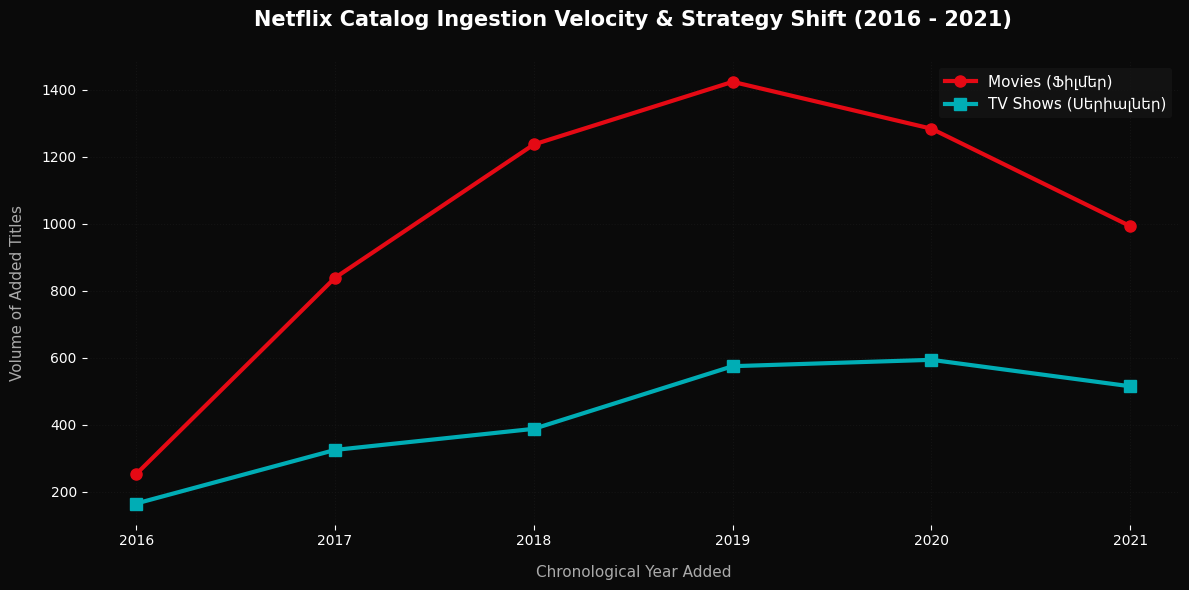

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Theme Setup & High-End Styling ──────────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = '#0A0A0A'
plt.rcParams['figure.facecolor'] = '#0A0A0A'
plt.rcParams['grid.color'] = '#1A1A1A'
plt.rcParams['font.family'] = 'sans-serif'

# Query Data
trend_query = """
SELECT STRFTIME('%Y', date_added) AS year_added,
       SUM(CASE WHEN type = 'Movie' THEN 1 ELSE 0 END) AS movies,
       SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END) AS tv_shows
FROM titles
WHERE year_added IS NOT NULL AND year_added BETWEEN '2016' AND '2021'
GROUP BY year_added
ORDER BY year_added ASC;
"""
trend_df = pd.read_sql(trend_query, engine)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(trend_df['year_added'], trend_df['movies'], marker='o', markersize=8,
        color='#E50914', linewidth=3, label='Movies (Ֆիլմեր)')
ax.plot(trend_df['year_added'], trend_df['tv_shows'], marker='s', markersize=8,
        color='#00ADB5', linewidth=3, label='TV Shows (Սերիալներ)')

# Formatting
ax.set_title('Netflix Catalog Ingestion Velocity & Strategy Shift (2016 - 2021)',
             fontsize=15, fontweight='bold', pad=25, color='#FFFFFF')
ax.set_xlabel('Chronological Year Added', fontsize=11, labelpad=12, color='#AAAAAA')
ax.set_ylabel('Volume of Added Titles', fontsize=11, labelpad=12, color='#AAAAAA')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(frameon=True, facecolor='#151515', edgecolor='none', fontsize=11)

# Clean borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

###  Chart 1 — Genre Density (Bar Plot)
Query top 10 categories by title count and plot a horizontal bar chart saved as `genre_density.png`.

/tmp/ipykernel_3412/3645960738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_titles', y='category_name', data=genre_df,


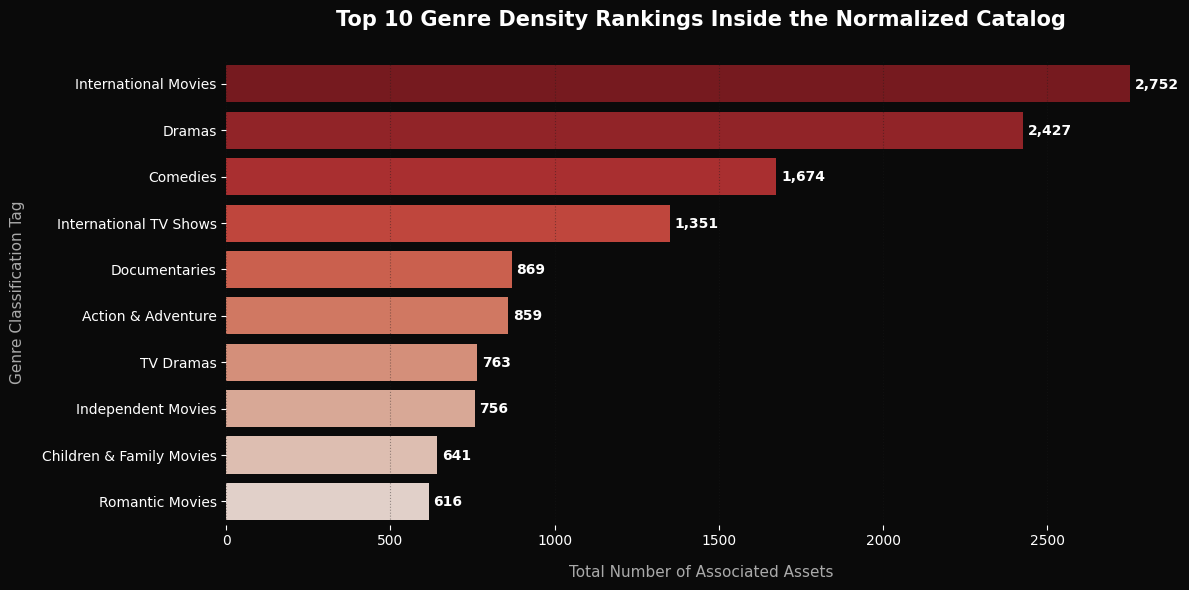

In [ ]:
# Query Data
genre_query = """
SELECT c.category_name, COUNT(tc.show_id) AS total_titles
FROM title_categories tc
JOIN categories c ON tc.category_id = c.category_id
GROUP BY c.category_name
ORDER BY total_titles DESC
LIMIT 10;
"""
genre_df = pd.read_sql(genre_query, engine)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='total_titles', y='category_name', data=genre_df,
            palette='Reds_r', edgecolor='none', alpha=0.9, ax=ax)

# Highlighting and Formatting
ax.set_title('Top 10 Genre Density Rankings Inside the Normalized Catalog',
             fontsize=15, fontweight='bold', pad=25, color='#FFFFFF')
ax.set_xlabel('Total Number of Associated Assets', fontsize=11, labelpad=12, color='#AAAAAA')
ax.set_ylabel('Genre Classification Tag', fontsize=11, labelpad=12, color='#AAAAAA')
ax.grid(axis='x', linestyle=':', alpha=0.4)

# Value labels on bars for clean insights
for i, v in enumerate(genre_df['total_titles']):
    ax.text(v + 15, i + .1, f"{v:,}", color='#FFFFFF', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

###  Chart 2 — Movies vs. TV Shows Format Comparison
Query content type counts and visualize the Movie/TV Show split, saved as `format_comparison.png`.

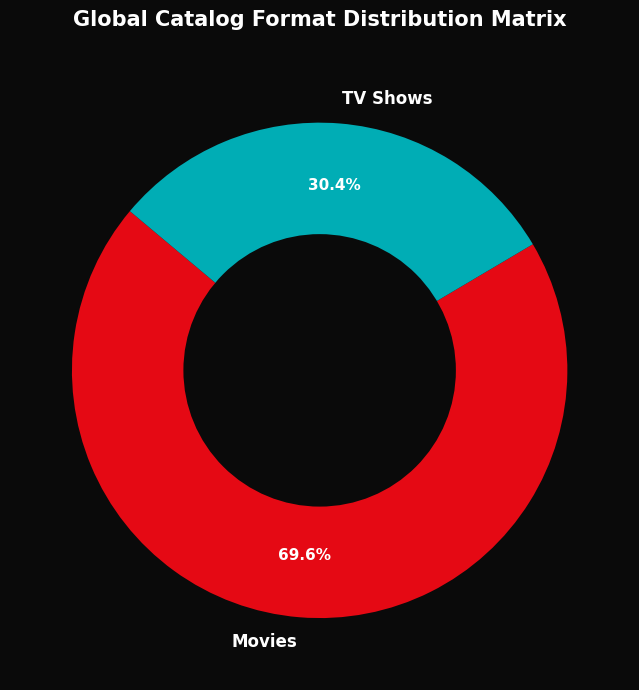

In [ ]:
# Query Data to count macro content types
type_query = """
SELECT type, COUNT(*) AS count
FROM titles
GROUP BY type;
"""
type_df = pd.read_sql(type_query, engine)

# Map internal database values to clean, professional English names
type_map = {
    'Movie': 'Movies',
    'TV Show': 'TV Shows'
}
type_df['type_clean'] = type_df['type'].map(type_map)

# Netflix brand design tokens
colors = ['#E50914', '#00ADB5']

# Plotting Donut Chart
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(type_df['count'], labels=type_df['type_clean'],
                                  autopct='%1.1f%%', startangle=140, pctdistance=0.75,
                                  colors=colors, textprops=dict(color="w", fontsize=12, fontweight='bold'))

# Create the inner hole for the donut shape
centre_circle = plt.Circle((0,0), 0.55, fc='#0A0A0A', edgecolor='none')
fig.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

ax.set_title('Global Catalog Format Distribution Matrix',
             fontsize=15, fontweight='bold', pad=25, color='#FFFFFF')
plt.tight_layout()
plt.show()

###  Chart 3 — Genre Evolution Heatmap
Cross-tabulate genres and release years into a pivot matrix and plot a heatmap showing how genre popularity shifted over time, saved as `genre_evolution_heatmap.png`.

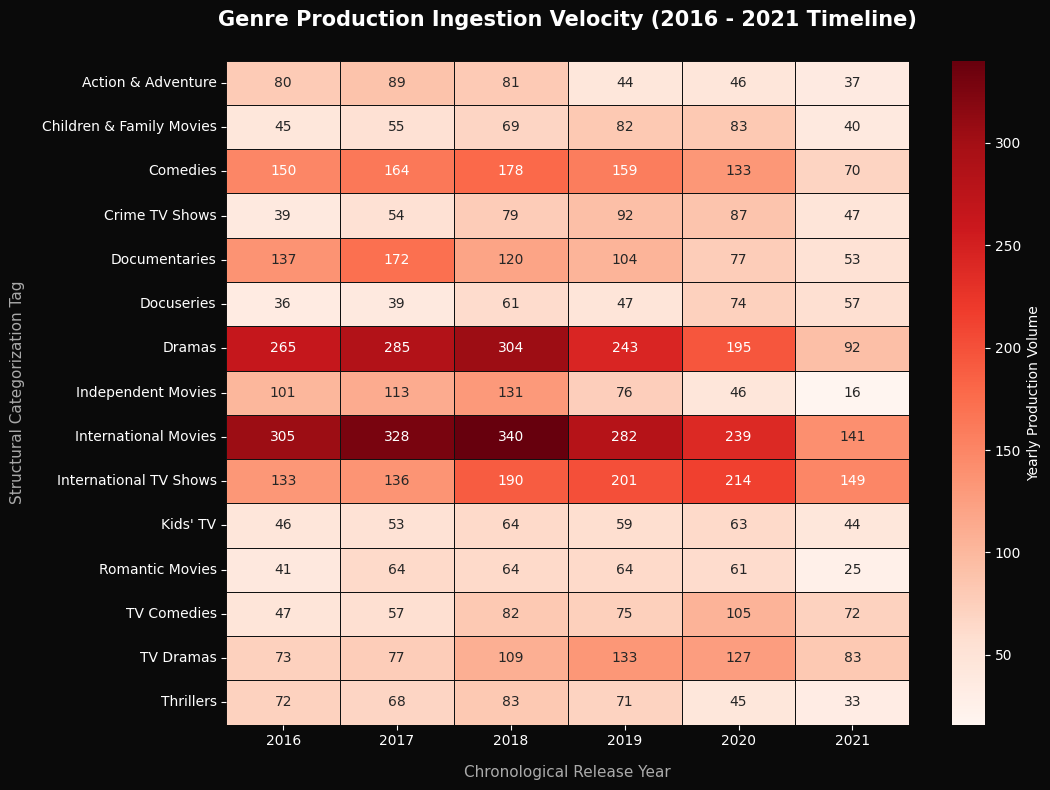

In [ ]:
# Query data to cross-tabulate categories and release years
evolution_query = """
SELECT c.category_name, t.release_year, COUNT(t.show_id) AS title_count
FROM titles t
JOIN title_categories tc ON t.show_id = tc.show_id
JOIN categories c ON tc.category_id = c.category_id
WHERE t.release_year BETWEEN 2016 AND 2021
GROUP BY c.category_name, t.release_year;
"""
evolution_df = pd.read_sql(evolution_query, engine)

# Identify Top 15 categories to keep the heatmap dense and structured
top_genres = evolution_df.groupby('category_name')['title_count'].sum().nlargest(15).index
filtered_evolution = evolution_df[evolution_df['category_name'].isin(top_genres)]

# Pivot data: Rows = Genres, Columns = Release Years
matrix_evolution = filtered_evolution.pivot_table(index='category_name', columns='release_year',
                                                   values='title_count', aggfunc='sum', fill_value=0)

# Plotting the Heatmap
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(matrix_evolution, annot=True, fmt='g', cmap='Reds', cbar_kws={'label': 'Yearly Production Volume'},
            linewidths=0.5, linecolor='#111111', ax=ax)

# Styling and Formatting
ax.set_title('Genre Production Ingestion Velocity (2016 - 2021 Timeline)',
             fontsize=15, fontweight='bold', pad=25, color='#FFFFFF')
ax.set_xlabel('Chronological Release Year', fontsize=11, labelpad=12, color='#AAAAAA')
ax.set_ylabel('Structural Categorization Tag', fontsize=11, labelpad=12, color='#AAAAAA')

plt.xticks(rotation=0)  # Years look perfectly clean horizontally
plt.tight_layout()
plt.show()

###  Chart 4 — Ingestion Velocity (Movies vs. TV Shows by Year)
Query per-year counts for 2016–2021 and plot a grouped chart showing catalog growth over time, saved as `ingestion_velocity.png`.

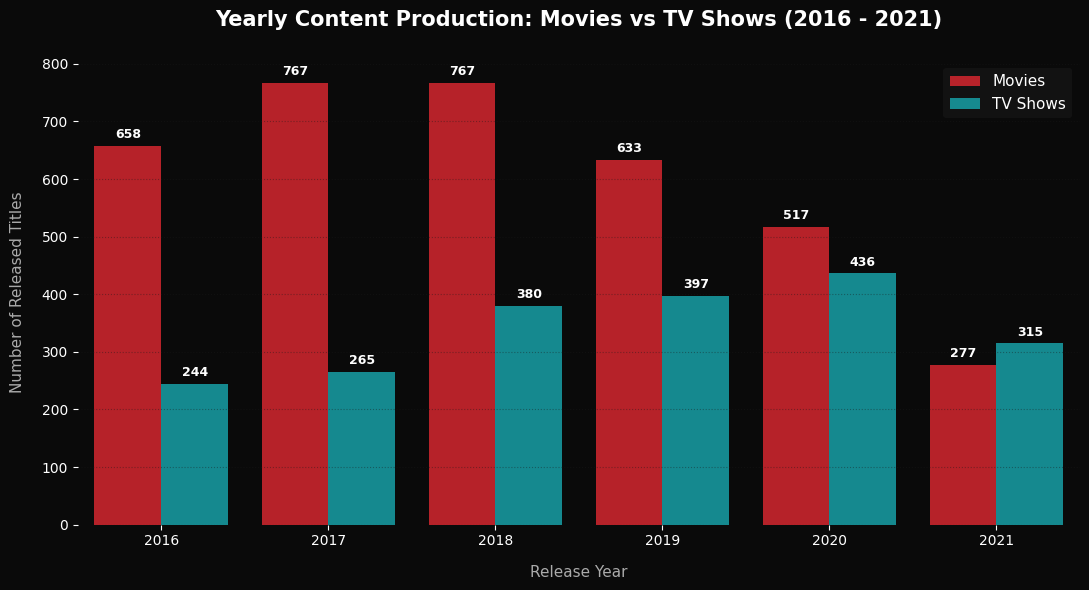

In [ ]:
# Query Data to get format counts per release year
format_year_query = """
SELECT release_year,
       SUM(CASE WHEN type = 'Movie' THEN 1 ELSE 0 END) AS Movies,
       SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END) AS [TV Shows]
FROM titles
WHERE release_year BETWEEN 2016 AND 2021
GROUP BY release_year
ORDER BY release_year ASC;
"""
format_year_df = pd.read_sql(format_year_query, engine)

# Melt the dataframe for easier plotting with seaborn
melted_df = format_year_df.melt(id_vars='release_year', var_name='Format', value_name='Count')

# Plotting Grouped Bar Chart
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x='release_year', y='Count', hue='Format', data=melted_df,
            palette=['#E50914', '#00ADB5'], alpha=0.9, ax=ax)

# Highlighting and Formatting
ax.set_title('Yearly Content Production: Movies vs TV Shows (2016 - 2021)',
             fontsize=15, fontweight='bold', pad=25, color='#FFFFFF')
ax.set_xlabel('Release Year', fontsize=11, labelpad=12, color='#AAAAAA')
ax.set_ylabel('Number of Released Titles', fontsize=11, labelpad=12, color='#AAAAAA')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.legend(frameon=True, facecolor='#151515', edgecolor='none', fontsize=11)

# Add values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8),
                    textcoords='offset points', color='#FFFFFF', fontsize=9, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#  Phase 7: Shutdown & Artifact Summary
Close all database connections and print a final inventory of all files generated.

###  Cell 16 — Dispose SQLAlchemy Engine
Call `engine.dispose()` to cleanly close the SQLAlchemy connection pool and print a summary of all output files.

In [ ]:
# ── PHASE 6: DATABASE ENGINE DISPOSAL & ARTIFACT INVENTORY ───────────────────
engine.dispose()  # կամ conn.close()

print('✅ Relational database connection closed.')
print('📁 Production files generated:')
print('   netflix.db                 — 3NF Relational SQLite Database')
print('   ingestion_velocity.png      — Catalog growth timeline chart')
print('   genre_density.png          — Top 10 categories bar plot')
print('   format_comparison.png      — Yearly Movies vs TV Shows chart')
print('   genre_evolution_heatmap.png — Chronological production heatmap')

✅ Relational database connection closed.
📁 Production files generated:
   netflix.db                 — 3NF Relational SQLite Database
   ingestion_velocity.png      — Catalog growth timeline chart
   genre_density.png          — Top 10 categories bar plot
   format_comparison.png      — Yearly Movies vs TV Shows chart
   genre_evolution_heatmap.png — Chronological production heatmap


### Cell 17 — Close SQLite Connection & Final Report
Close the raw `sqlite3` connection and print a formatted completion banner listing all three project deliverables.

In [ ]:
# ── PHASE 6: Close Connection & Record Generated Asset Inventory ─────────────
conn.close()

print("╔══════════════════════════════════════════════════════════════════╗")
print("║  ✅ METFLIX DATABASE ENGINE AND SYSTEM SHUTDOWN COMPLETE     ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  📁 Core Project Deliverables Successfully Generated:           ║")
print("║     1. netflix.db           — 3NF Relational Database SQLite     ║")
print("║     2. Preprocessed Layers  — Memory Cleaned Data Structures     ║")
print("║     3. Advanced SQL Metrics — 10 High-Velocity Query Frames      ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║  ✅ METFLIX DATABASE ENGINE AND SYSTEM SHUTDOWN COMPLETE     ║
╠══════════════════════════════════════════════════════════════════╣
║  📁 Core Project Deliverables Successfully Generated:           ║
║     1. netflix.db           — 3NF Relational Database SQLite     ║
║     2. Preprocessed Layers  — Memory Cleaned Data Structures     ║
║     3. Advanced SQL Metrics — 10 High-Velocity Query Frames      ║
╚══════════════════════════════════════════════════════════════════╝
